### ====================================================================
## 0. IMPORT REQUIRED PACKAGES
### ====================================================================

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage

### ====================================================================
## 1. SIMULATION PARAMETERS & TOGGLES
### ====================================================================
Change ```ENABLE_MOTION``` to view the effect of motion.

In [13]:
GRID_SIZE = 128
ENABLE_MOTION = True  # Toggle to True/False to compare ideal vs motion-corrupted T1 maps
SNR_TARGET = 20       # Target SNR in the renal cortex
TIs = np.array([100, 300, 600, 1000, 1800, 3000]) # Inversion Times (ms)

# T1 (ms) and Proton Density/System Gain (S0) values
PROPS = {
    'cortex':  {'T1': 1100, 'S0': 1000},
    'medulla': {'T1': 1500, 'S0': 850},
    'pelvis':  {'T1': 380,  'S0': 1200},  # Hilar fat has short T1 and high S0
    'bg':      {'T1': 1e6,  'S0': 0}      # Background (T1 ~ infinity)
}

### ====================================================================
## 2. CREATE RENAL PHANTOM
### ====================================================================

In [14]:
def generate_renal_phantom(size=GRID_SIZE):
    """
    Creates a realistic 2D kidney phantom using analytical geometric constraints 
    and polar coordinate perturbations (Fourier-like descriptors).
    """
    # Create normalized coordinate grid [-1.5, 1.5]
    x = np.linspace(-1.5, 1.5, size)
    y = np.linspace(-1.5, 1.5, size)
    X, Y = np.meshgrid(x, y)
    
    # Global Polar Coordinates
    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)
    
    # 1. Kidney Parenchyma Silhouette (Bean Shape)
    # We use an exponential perturbation to create an indentation (hilum) at Theta = 0.
    R_kidney_bound = 1.0 - 0.4 * np.exp(- (Theta)**2 / 0.3)
    mask_kidney = R < R_kidney_bound
    
    # 2. Renal Pelvis / Sinus Fat
    # Shifted slightly right (medially) towards the hilum indentation
    mask_pelvis = ((X - 0.2)**2 + (Y)**2) < 0.3**2
    mask_pelvis = mask_pelvis & mask_kidney
    
    # 3. Medullary Pyramids
    # Calculate polar coordinates relative to the hilar center (0.2, 0)
    Theta_p = np.arctan2(Y, X - 0.2)
    R_p = np.sqrt((X - 0.2)**2 + Y**2)
    
    # Use a sinusoidal angular mask to create 6 distinct radial wedges.
    # np.sin(3 * Theta_p) produces 3 full periods (6 lobes/pyramids).
    wedge_mask = np.abs(np.sin(3 * Theta_p)) > 0.6
    
    # Constrain the wedges radially to sit between the pelvis and the outer cortex
    mask_medulla = wedge_mask & (R_p > 0.35) & (R_p < 0.8) & mask_kidney & ~mask_pelvis
    
    # 4. Renal Cortex (Everything left over in the kidney mask)
    mask_cortex = mask_kidney & ~mask_pelvis & ~mask_medulla
    
    # 5. Populate T1 and S0 Maps
    T1_map = np.ones((size, size)) * PROPS['bg']['T1']
    S0_map = np.zeros((size, size))
    
    # Apply properties
    T1_map[mask_cortex]  = PROPS['cortex']['T1']
    S0_map[mask_cortex]  = PROPS['cortex']['S0']
    
    T1_map[mask_medulla] = PROPS['medulla']['T1']
    S0_map[mask_medulla] = PROPS['medulla']['S0']
    
    T1_map[mask_pelvis]  = PROPS['pelvis']['T1']
    S0_map[mask_pelvis]  = PROPS['pelvis']['S0']
    
    # Store masks for later ROI extraction
    masks = {'cortex': mask_cortex, 'medulla': mask_medulla}
    return T1_map, S0_map, masks

T1_true, S0_true, rois = generate_renal_phantom(GRID_SIZE)

### ====================================================================
## 3. SIMULATE INVERSION RECOVERY SEQUENCE
### ====================================================================

In [15]:
def simulate_ir_sequence(T1, S0, TIs, enable_motion=False, snr=SNR_TARGET):
    """
    Simulates T1-weighted magnitude Inversion Recovery images.
    Applies Rician noise and optional respiratory motion.
    """
    images = []
    
    # Rician noise calculation: Sigma derived from baseline S0 in cortex
    noise_sigma = PROPS['cortex']['S0'] / snr
    
    for i, ti in enumerate(TIs):
        # 1. Ideal Inversion Recovery Physics
        # Base signal before magnitude operation allows for negative magnetization
        S_ideal = S0 * (1 - 2 * np.exp(-ti / T1))
        
        # 2. Respiratory Motion (Rigid translation + Non-rigid stretching)
        if enable_motion:
            # Simulate a diaphragm moving up and down (sinusoidal over TI acquisitions)
            # shift_y: pixel translation. stretch_y: tissue compression/expansion
            shift_y = 4 * np.sin(2 * np.pi * 0.4 * i)
            stretch_y = 1.0 + 0.05 * np.sin(2 * np.pi * 0.4 * i)
            
            # Affine transformation matrix
            matrix = np.array([[1.0, 0], 
                               [0, stretch_y]])
            offset = [0, shift_y]
            
            # Apply transformation (uses spline interpolation)
            S_shifted = ndimage.affine_transform(S_ideal, matrix, offset=offset, order=1)
        else:
            S_shifted = S_ideal
            
        # 3. Real Rician Noise Addition
        # True MRI noise occurs in the quadrature receiving coils (Complex Gaussian)
        # The magnitude operation turns this into a Rician distribution.
        noise_r = np.random.normal(0, noise_sigma, S_shifted.shape)
        noise_i = np.random.normal(0, noise_sigma, S_shifted.shape)
        
        # Magnitude Calculation: S(TI) = | S_ideal + Noise |
        S_mag = np.sqrt((S_shifted + noise_r)**2 + noise_i**2)
        images.append(S_mag)
        
    return np.array(images)

TI_series = simulate_ir_sequence(T1_true, S0_true, TIs, enable_motion=ENABLE_MOTION)

### ====================================================================
## 3.1 SIMULATE IR MODEL AND RECONSTRUCT T1 MAP
### ====================================================================

In [16]:
def ir_model(ti, s0, t1):
    """ Magnitude inversion recovery model for curve fitting """
    return np.abs(s0 * (1 - 2 * np.exp(-ti / t1)))

def reconstruct_t1_map(series, TIs):
    """
    Pixel-wise curve fitting to estimate T1 from the multi-TI magnitude series.
    """
    size = series.shape[1]
    T1_fit = np.zeros((size, size))
    
    print("Reconstructing T1 Map. Fitting pixels, please wait...")
    for r in range(size):
        for c in range(size):
            # Mask out background to save computation time (mean signal > 100)
            if np.mean(series[:, r, c]) > 100:
                try:
                    # p0 is the initial guess for [S0, T1]
                    # bounds constrain S0: [0, 3000] and T1: [0, 5000]
                    popt, _ = curve_fit(ir_model, TIs, series[:, r, c], 
                                        p0=[1000, 1000], 
                                        bounds=(0, [3000, 5000]),
                                        maxfev=1000)
                    T1_fit[r, c] = popt[1]
                except RuntimeError:
                    # If curve fitting fails to converge
                    T1_fit[r, c] = 0
    return T1_fit
T1_reconstructed = reconstruct_t1_map(TI_series, TIs)

Reconstructing T1 Map. Fitting pixels, please wait...


### ====================================================================
## 4. PLOT THE RESULTS
### ====================================================================

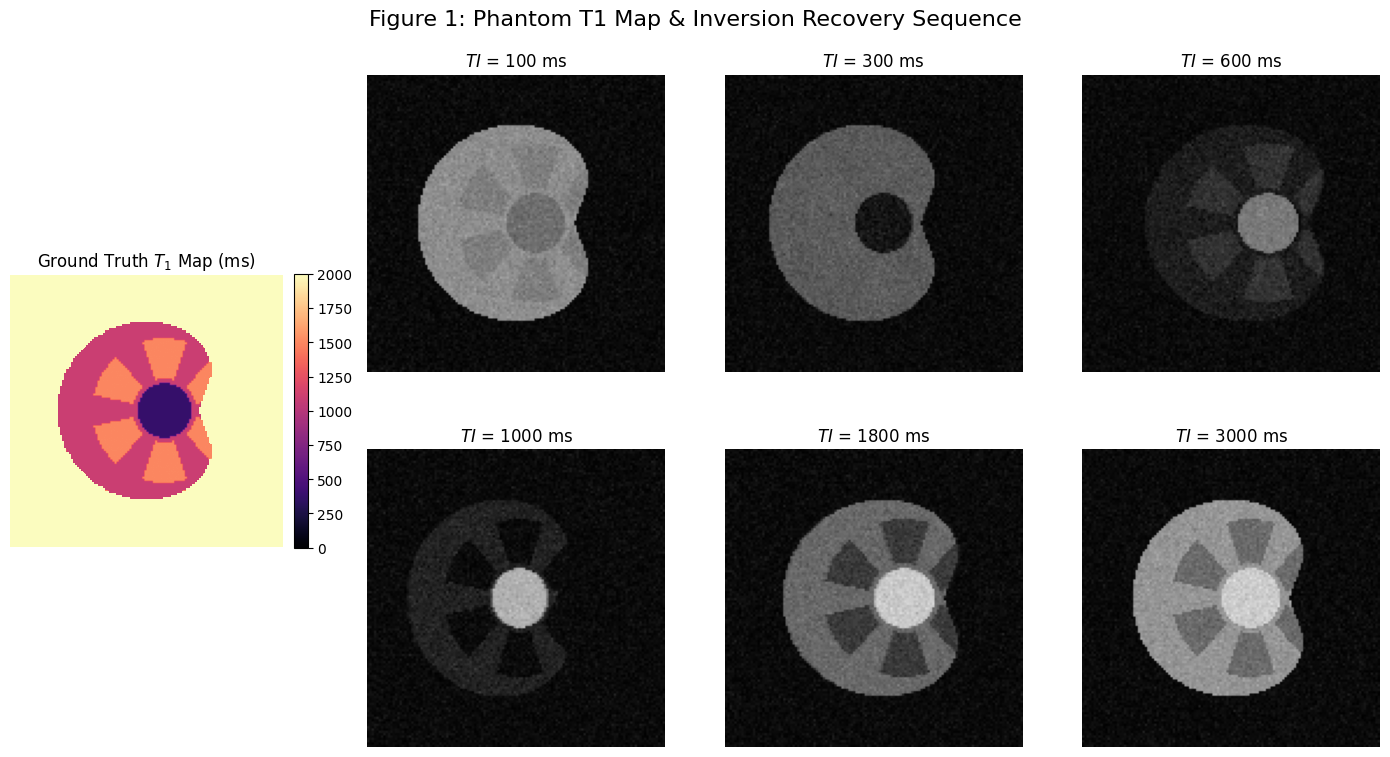

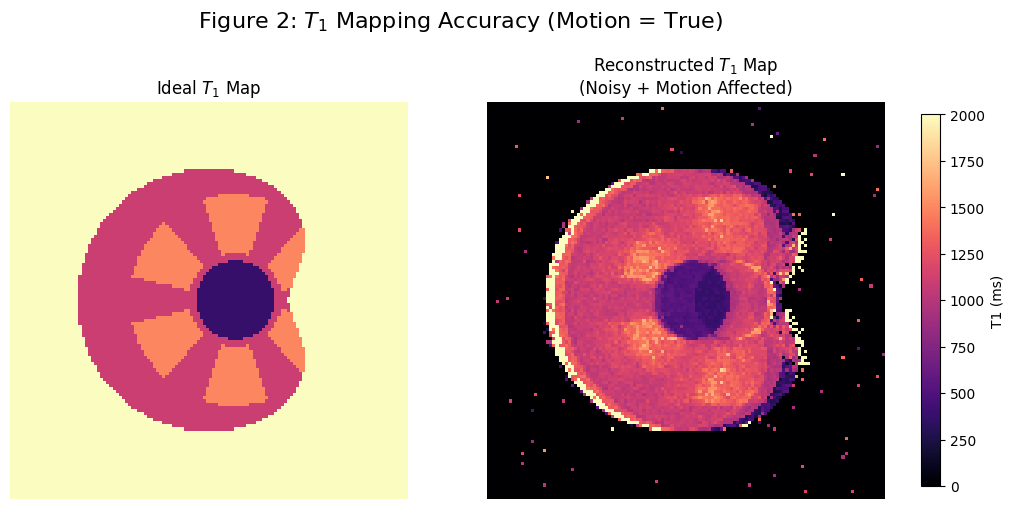

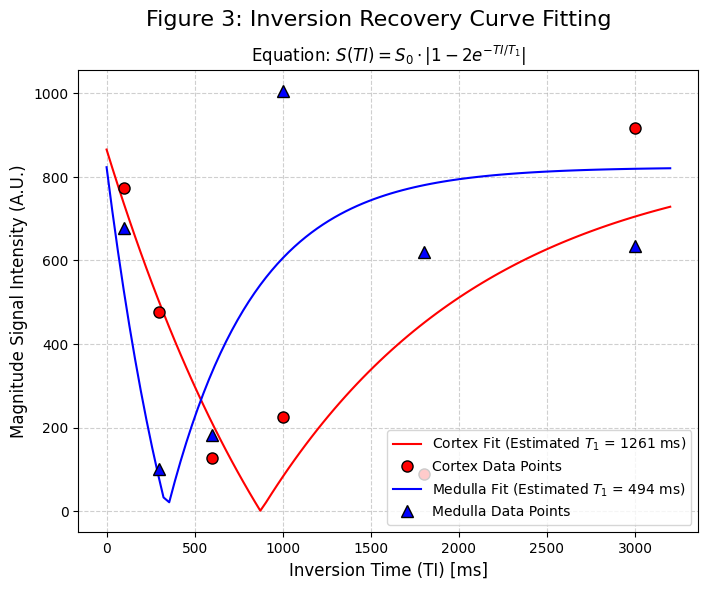

In [17]:
fig1 = plt.figure(figsize=(14, 8))
plt.suptitle("Figure 1: Phantom T1 Map & Inversion Recovery Sequence", fontsize=16)

# Ground Truth T1 Map
ax_gt = plt.subplot(2, 4, (1, 5))
im_gt = ax_gt.imshow(T1_true, cmap='magma', vmin=0, vmax=2000)
ax_gt.set_title("Ground Truth $T_1$ Map (ms)")
ax_gt.axis('off')
plt.colorbar(im_gt, ax=ax_gt, fraction=0.046, pad=0.04)

# 2x3 Grid of TI Series
for i, ti in enumerate(TIs):
    ax_ti = plt.subplot(2, 4, i + 2 if i < 3 else i + 3)
    ax_ti.imshow(TI_series[i], cmap='gray', vmin=0, vmax=1500)
    ax_ti.set_title(f"$TI$ = {ti} ms")
    ax_ti.axis('off')
plt.tight_layout()

# --- Figure 2: Ground Truth vs. Reconstructed T1 Map ---
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig2.suptitle(f"Figure 2: $T_1$ Mapping Accuracy (Motion = {ENABLE_MOTION})", fontsize=16)

im1 = ax1.imshow(T1_true, cmap='magma', vmin=0, vmax=2000)
ax1.set_title("Ideal $T_1$ Map")
ax1.axis('off')

# Display reconstructed map (will show blurring and striping if motion=True)
im2 = ax2.imshow(T1_reconstructed, cmap='magma', vmin=0, vmax=2000)
ax2.set_title("Reconstructed $T_1$ Map\n(Noisy + Motion Affected)")
ax2.axis('off')

plt.colorbar(im2, ax=[ax1, ax2], fraction=0.02, pad=0.04, label="T1 (ms)")


# --- Figure 3: Single-Pixel Curve Fitting ---
# Find a representative pixel inside the cortex and medulla using our masks
cortex_coords = np.argwhere(rois['cortex'])
medulla_coords = np.argwhere(rois['medulla'])

# Pick pixels near the middle of the arrays
cx, cy = cortex_coords[len(cortex_coords)//2]
mx, my = medulla_coords[len(medulla_coords)//2]

# Extract multi-TI signal data for those specific pixels
sig_cortex = TI_series[:, cx, cy]
sig_medulla = TI_series[:, mx, my]

# Generate smooth curves for the plotted fits using reconstructed parameters
ti_smooth = np.linspace(0, 3200, 100)

# Retrieve the fitted parameters for these specific pixels
popt_c, _ = curve_fit(ir_model, TIs, sig_cortex, p0=[1000, 1000], bounds=(0, [3000, 5000]))
popt_m, _ = curve_fit(ir_model, TIs, sig_medulla, p0=[1000, 1000], bounds=(0, [3000, 5000]))

fit_cortex = ir_model(ti_smooth, *popt_c)
fit_medulla = ir_model(ti_smooth, *popt_m)

fig3, ax = plt.subplots(figsize=(8, 6))
fig3.suptitle("Figure 3: Inversion Recovery Curve Fitting", fontsize=16)

# Cortex Plot
ax.plot(ti_smooth, fit_cortex, 'r-', label=f"Cortex Fit (Estimated $T_1$ = {popt_c[1]:.0f} ms)")
ax.plot(TIs, sig_cortex, 'ro', markersize=8, markeredgecolor='k', label="Cortex Data Points")

# Medulla Plot
ax.plot(ti_smooth, fit_medulla, 'b-', label=f"Medulla Fit (Estimated $T_1$ = {popt_m[1]:.0f} ms)")
ax.plot(TIs, sig_medulla, 'b^', markersize=8, markeredgecolor='k', label="Medulla Data Points")

ax.set_xlabel("Inversion Time (TI) [ms]", fontsize=12)
ax.set_ylabel("Magnitude Signal Intensity (A.U.)", fontsize=12)
ax.set_title("Equation: $S(TI) = S_0 \\cdot |1 - 2e^{-TI / T_1}|$", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=10)

plt.show()